✅ Đã đọc thành công 30,336 bản ghi từ MySQL


12:01:04 - cmdstanpy - INFO - Chain [1] start processing
12:01:19 - cmdstanpy - INFO - Chain [1] done processing


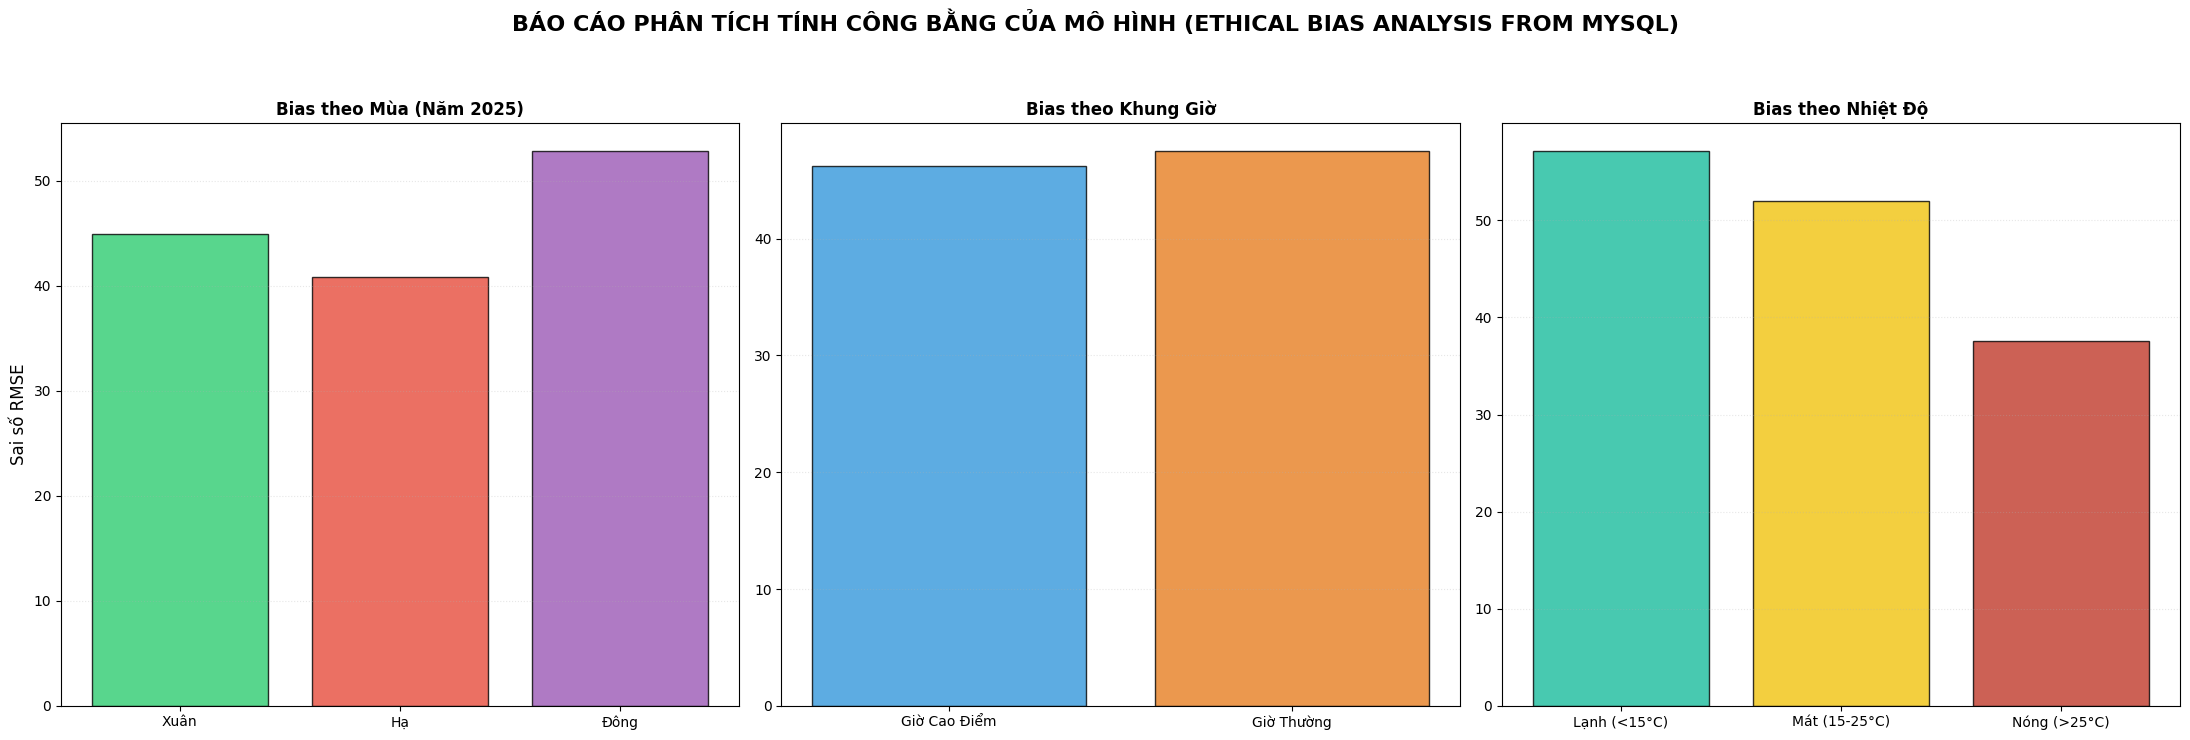

🎉 Hoàn thành phân tích Bias.
📁 Ảnh đã lưu tại: C:\Users\BUI QUANG HUNG\Air-Quality-Index-in-Hanoi-\library_framework\charts\prophet_bias_analysis.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from sqlalchemy import create_engine
import warnings
import os
from dotenv import load_dotenv
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)

# =========================================================
# PHÂN HỆ ĐỊNH VỊ ĐƯỜNG DẪN ĐỘNG
# =========================================================
current_dir = Path(os.getcwd()).resolve()

if 'library_framework' in current_dir.parts:

    dotenv_path = current_dir.parent / '.env'

    # Lưu đúng vào library_framework/charts
    charts_dir = current_dir / 'charts'

else:

    dotenv_path = current_dir / '.env'

    # Nếu chạy từ thư mục gốc project
    charts_dir = current_dir / 'library_framework' / 'charts'

# Load biến môi trường
load_dotenv(dotenv_path=dotenv_path)

# Tạo folder charts nếu chưa có
os.makedirs(charts_dir, exist_ok=True)

# =========================================================
# KẾT NỐI MYSQL
# =========================================================
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# =========================================================
# LOAD DATA
# =========================================================
try:

    query = "SELECT * FROM aqi_data"

    df = pd.read_sql(query, con=engine)

    print(f"✅ Đã đọc thành công {len(df):,} bản ghi từ MySQL")

except Exception as e:

    print(f"❌ Lỗi MySQL: {e}")

    raise SystemExit()

# =========================================================
# TIỀN XỬ LÝ
# =========================================================
df.columns = df.columns.str.strip().str.lower()

df['ds'] = pd.to_datetime(df['local_time'])

df['y'] = pd.to_numeric(df['aqi'], errors='coerce')

df['temperature'] = pd.to_numeric(df['temperature'], errors='coerce')

df['is_rush_hour'] = pd.to_numeric(df['is_rush_hour'], errors='coerce')

df['season'] = pd.to_numeric(df['season'], errors='coerce')

df = df.dropna(subset=['ds', 'y'])

# =========================================================
# TRAIN / TEST
# =========================================================
train = df[df['ds'] < '2025-01-01']

test = df[
    (df['ds'] >= '2025-01-01') &
    (df['ds'] <= '2025-06-30')
]

# =========================================================
# TRAIN PROPHET
# =========================================================
model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True
)

model.fit(train)

future = model.make_future_dataframe(
    periods=len(test),
    freq='h'
)

forecast = model.predict(future)

# =========================================================
# EVALUATION
# =========================================================
eval_df = test.copy()

forecast_test = forecast.set_index('ds').loc[test['ds']]

eval_df['pred'] = forecast_test['yhat'].values

# =========================================================
# MAP MÙA
# =========================================================
eval_df['season_name'] = eval_df['season'].map({
    0: 'Đông',
    1: 'Xuân',
    2: 'Hạ',
    3: 'Thu'
})

eval_df['hour_type'] = eval_df['is_rush_hour'].map({
    1: 'Giờ Cao Điểm',
    0: 'Giờ Thường'
})

# =========================================================
# NHÓM NHIỆT ĐỘ
# =========================================================
eval_df['temp_group'] = pd.cut(
    eval_df['temperature'],
    bins=[-10, 15, 25, 50],
    labels=[
        'Lạnh (<15°C)',
        'Mát (15-25°C)',
        'Nóng (>25°C)'
    ]
)

# =========================================================
# HÀM RMSE
# =========================================================
def calc_rmse(group):

    if len(group) == 0:
        return np.nan

    return np.sqrt(
        mean_squared_error(group['y'], group['pred'])
    )

# =========================================================
# RMSE THEO MÙA
# =========================================================
rmse_season = eval_df.groupby(
    'season_name'
).apply(calc_rmse)

# Chỉ lấy các mùa thực sự tồn tại trong dữ liệu
labels_s = [
    x for x in ['Xuân', 'Hạ', 'Thu', 'Đông']
    if x in rmse_season.index
]

vals_s = [rmse_season[x] for x in labels_s]

# =========================================================
# RMSE THEO KHUNG GIỜ
# =========================================================
rmse_hour = eval_df.groupby(
    'hour_type'
).apply(calc_rmse)

# =========================================================
# RMSE THEO NHIỆT ĐỘ
# =========================================================
rmse_temp = eval_df.groupby(
    'temp_group'
).apply(calc_rmse)

# =========================================================
# VẼ BIỂU ĐỒ
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# =========================================================
# BIAS THEO MÙA
# =========================================================
season_colors = {
    'Xuân': '#2ecc71',
    'Hạ': '#e74c3c',
    'Thu': '#ff8c00',
    'Đông': '#9b59b6'
}

axes[0].bar(
    labels_s,
    vals_s,
    color=[season_colors[x] for x in labels_s],
    edgecolor='black',
    alpha=0.8
)

axes[0].set_title(
    'Bias theo Mùa (Năm 2025)',
    fontweight='bold',
    fontsize=12
)

axes[0].set_ylabel(
    'Sai số RMSE',
    fontsize=12
)

axes[0].grid(
    axis='y',
    alpha=0.3,
    linestyle=':'
)

# =========================================================
# BIAS THEO KHUNG GIỜ
# =========================================================
axes[1].bar(
    rmse_hour.index,
    rmse_hour.values,
    color=['#3498db', '#e67e22'],
    edgecolor='black',
    alpha=0.8
)

axes[1].set_title(
    'Bias theo Khung Giờ',
    fontweight='bold',
    fontsize=12
)

axes[1].grid(
    axis='y',
    alpha=0.3,
    linestyle=':'
)

# =========================================================
# BIAS THEO NHIỆT ĐỘ
# =========================================================
axes[2].bar(
    rmse_temp.index.astype(str),
    rmse_temp.values,
    color=['#1abc9c', '#f1c40f', '#c0392b'],
    edgecolor='black',
    alpha=0.8
)

axes[2].set_title(
    'Bias theo Nhiệt Độ',
    fontweight='bold',
    fontsize=12
)

axes[2].grid(
    axis='y',
    alpha=0.3,
    linestyle=':'
)

# =========================================================
# TITLE
# =========================================================
plt.suptitle(
    'BÁO CÁO PHÂN TÍCH TÍNH CÔNG BẰNG CỦA MÔ HÌNH (ETHICAL BIAS ANALYSIS FROM MYSQL)',
    fontsize=16,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()

# =========================================================
# SAVE ẢNH
# =========================================================
output_path = os.path.join(
    charts_dir,
    'prophet_bias_analysis.png'
)

plt.savefig(
    output_path,
    bbox_inches='tight',
    dpi=300
)

plt.show()

# =========================================================
# THÔNG BÁO
# =========================================================
print(f"🎉 Hoàn thành phân tích Bias.")
print(f"📁 Ảnh đã lưu tại: {output_path}")

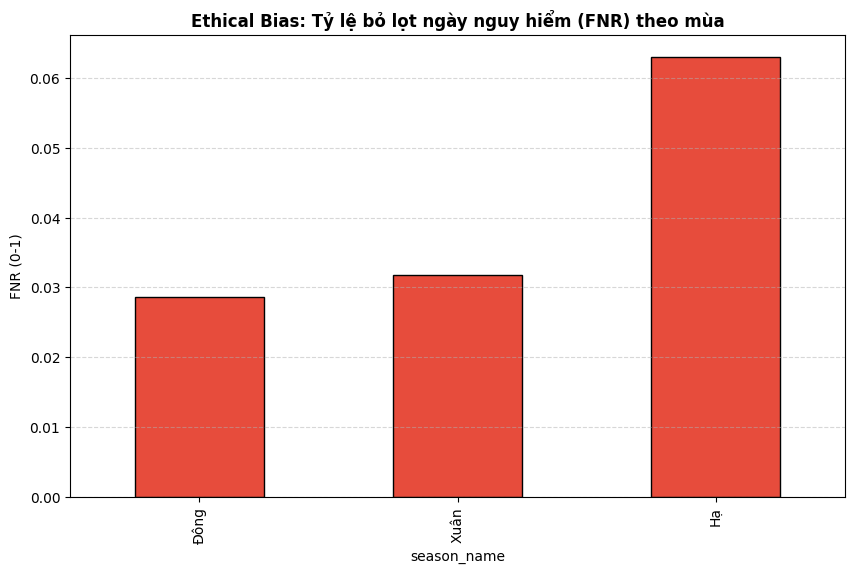

✅ Đã lưu biểu đồ tại: C:\Users\BUI QUANG HUNG\Air-Quality-Index-in-Hanoi-\library_framework\charts\fnr_season_plot.png
✅ Đã lưu biểu đồ FNR tại: C:\Users\BUI QUANG HUNG\Air-Quality-Index-in-Hanoi-\library_framework\charts\fnr_season_plot.png


In [7]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. LOAD MODEL VÀ CHUẨN BỊ DỮ LIỆU
FEATURES_CLASSIFICATION = [
    'co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 
    'clouds', 'precipitation', 'pressure', 'relative_humidity', 
    'temperature', 'uv_index', 'wind_speed', 
    'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season'
]

model_clf = joblib.load('library_framework/best_model_classification.pkl')
df_clean = df.dropna(subset=FEATURES_CLASSIFICATION).copy()

# 2. DỰ BÁO
df_clean['pred_class'] = model_clf.predict(df_clean[FEATURES_CLASSIFICATION])
df_clean['actual_risk'] = (df_clean['y'] >= 100).astype(int)

# 3. TÍNH TOÁN ETHICAL BIAS (FNR)
def calculate_fnr(group):
    if group['actual_risk'].sum() == 0: return 0
    # Dùng confusion_matrix an toàn
    cm = confusion_matrix(group['actual_risk'], group['pred_class'], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else 0

df_clean['season_name'] = df_clean['season'].map({0: 'Đông', 1: 'Xuân', 2: 'Hạ', 3: 'Thu'})
fnr_season = df_clean.groupby('season_name').apply(calculate_fnr, include_groups=False).dropna()

# 4. VẼ VÀ LƯU ẢNH (Gộp tất cả vào 1 hình duy nhất để không bị lỗi file trống)
plt.figure(figsize=(10, 6))
order = [m for m in ['Đông', 'Xuân', 'Hạ', 'Thu'] if m in fnr_season.index]
fnr_season.reindex(order).plot(kind='bar', color='#e74c3c', edgecolor='black')

plt.title('Ethical Bias: Tỷ lệ bỏ lọt ngày nguy hiểm (FNR) theo mùa', fontweight='bold')
plt.ylabel('FNR (0-1)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. LƯU ẢNH CHUẨN XÁC VÀO THƯ MỤC STREAMLIT
from pathlib import Path
import os

current_dir = Path(os.getcwd()).resolve()
if 'library_framework' in current_dir.parts:
    charts_dir = current_dir / 'charts'
else:
    charts_dir = current_dir / 'library_framework' / 'charts'

os.makedirs(charts_dir, exist_ok=True)

save_path = charts_dir / 'fnr_season_plot.png'

plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Đã lưu biểu đồ tại: {save_path}")
print(f"✅ Đã lưu biểu đồ FNR tại: {save_path}")

Đã lưu tại: C:\Users\BUI QUANG HUNG\Air-Quality-Index-in-Hanoi-\library_framework\charts\regression_bias_analysis.png
Đã lưu ảnh xong!


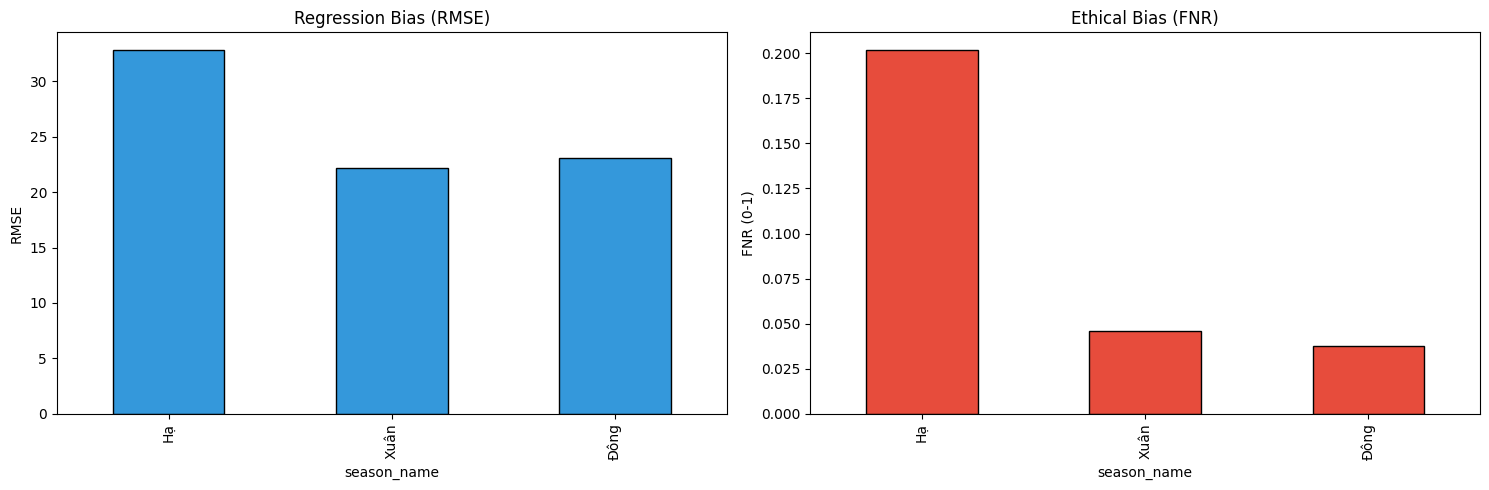

In [8]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. LOAD DATA
# Đảm bảo đường dẫn này đúng với vị trí file của bạn
df = pd.read_csv('library_framework/forecast_results_2025.csv')

# 2. ĐỊNH NGHĨA CỘT (Feature Engineering)
df['datetime'] = pd.to_datetime(df['local_time'])
df['y'] = df['aqi']  
for lag in [1, 2, 3, 6, 12, 24, 48, 168]: df[f'aqi_lag_{lag}'] = df['aqi'].shift(lag)
df['aqi_roll_6'] = df['aqi'].shift(1).rolling(6).mean()
df['aqi_roll_12'] = df['aqi'].shift(1).rolling(12).mean()
df['aqi_roll_24'] = df['aqi'].shift(1).rolling(24).mean()
df['aqi_roll_48'] = df['aqi'].shift(1).rolling(48).mean()
df['aqi_ema_12'] = df['aqi'].shift(1).ewm(span=12).mean()
df['aqi_ema_24'] = df['aqi'].shift(1).ewm(span=24).mean()
df['aqi_trend_1'] = df['aqi_lag_1'] - df['aqi_lag_2']
df['aqi_trend_6'] = df['aqi_lag_1'] - df['aqi_lag_6']
df['aqi_trend_24'] = df['aqi_lag_1'] - df['aqi_lag_24']
df['pm25_lag_1'] = df['pm25'].shift(1)
df['pm25_lag_6'] = df['pm25'].shift(6)
df['pm25_lag_24'] = df['pm25'].shift(24)
df['pm25_roll_24'] = df['pm25'].shift(1).rolling(24).mean()
df['pm25_ema_24'] = df['pm25'].shift(1).ewm(span=24).mean()
df['pm10_lag_1'] = df['pm10'].shift(1)

WEATHER_LAG_COLS = ['clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed']
for col in WEATHER_LAG_COLS: df[f'{col}_lag_1'] = df[col].shift(1)
df = df.dropna().copy()

df['season_name'] = df['season'].map({0: 'Đông', 1: 'Xuân', 2: 'Hạ', 3: 'Thu'})

FEATURES = [
    'clouds_lag_1', 'precipitation_lag_1', 'pressure_lag_1', 'relative_humidity_lag_1', 'temperature_lag_1', 'uv_index_lag_1', 'wind_speed_lag_1',
    'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season',
    'aqi_lag_1', 'aqi_lag_2', 'aqi_lag_3', 'aqi_lag_6', 'aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48', 'aqi_lag_168',
    'aqi_roll_6', 'aqi_roll_12', 'aqi_roll_24', 'aqi_roll_48', 'aqi_ema_12', 'aqi_ema_24',
    'aqi_trend_1', 'aqi_trend_6', 'aqi_trend_24', 'pm25_lag_1', 'pm25_lag_6', 'pm25_lag_24', 'pm25_roll_24', 'pm25_ema_24', 'pm10_lag_1'
]

# 3. DỰ BÁO
model_clf = joblib.load('best_model.pkl') 
df['pred'] = model_clf.predict(df[FEATURES])

# 4. TÍNH TOÁN BIAS
rmse_season = df.groupby('season_name').apply(lambda g: np.sqrt(mean_squared_error(g['y'], g['pred'])), include_groups=False)
df['actual_risk'] = (df['y'] >= 100).astype(int)
df['pred_risk'] = (df['pred'] >= 100).astype(int)
fnr = df[df['actual_risk'] == 1].groupby('season_name')['pred_risk'].apply(lambda x: 1 - x.mean())

# 5. VẼ VÀ LƯU ẢNH (Gộp lại thành 1 hình duy nhất để Streamlit hiển thị đẹp)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rmse_season.plot(kind='bar', color='#3498db', edgecolor='black', ax=axes[0])
axes[0].set_title('Regression Bias (RMSE)'); axes[0].set_ylabel('RMSE')

fnr.plot(kind='bar', color='#e74c3c', edgecolor='black', ax=axes[1])
axes[1].set_title('Ethical Bias (FNR)'); axes[1].set_ylabel('FNR (0-1)')

plt.tight_layout()

from pathlib import Path
import os

current_dir = Path(os.getcwd()).resolve()

if 'library_framework' in current_dir.parts:
    charts_dir = current_dir / 'charts'
else:
    charts_dir = current_dir / 'library_framework' / 'charts'

os.makedirs(charts_dir, exist_ok=True)

save_path = charts_dir / 'regression_bias_analysis.png'

plt.savefig(save_path, bbox_inches='tight', dpi=300)

print(f"Đã lưu tại: {save_path}")
print("Đã lưu ảnh xong!")